<a href="https://colab.research.google.com/github/Sievv/Sievv/blob/main/CD_HIT_METHOD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# ============================================================
# CD-HIT-2D for KP, EC, PS from CSV files directly
# Thresholds: 90%, 80%, 70%
# ============================================================

!apt-get update -qq
!apt-get install -y cd-hit
!pip install -q biopython pandas

import os
import pandas as pd
from Bio import SeqIO

# ============================================================
# 1. Set your CSV paths here
# ============================================================

datasets = {
    "KP": {
        "name": "K. pneumoniae",
        "train_csv": "/content/drive/MyDrive/KP/KP imbalance/KP_train_clean_for_CDHIT.csv", # Corrected path
        "test_csv": "/content/drive/MyDrive/KP/KP imbalance/KP_test_clean_for_CDHIT.csv"   # Corrected path
    },
    "EC": {
        "name": "E. coli",
        "train_csv": "/content/drive/MyDrive/EC/EC imbalance/EC_train_clean_for_CDHIT.csv",
        "test_csv": "/content/drive/MyDrive/EC/EC imbalance/EC_test_clean_for_CDHIT.csv"
    },
    "PS": {
        "name": "P. aeruginosa",
        "train_csv": "/content/drive/MyDrive/PS/PS imbalance/PS_train_clean_for_CDHIT.csv",
        "test_csv": "/content/drive/MyDrive/PS/PS imbalance/PS_test_clean_for_CDHIT.csv"
    }
}

seq_col = "Sequence"

thresholds = {
    90: {"c": 0.90, "n": 5},
    80: {"c": 0.80, "n": 5},
    70: {"c": 0.70, "n": 4}
}

output_dir = "/content/CDHIT_all_results"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# 2. Helper functions
# ============================================================

def clean_csv_and_make_fasta(csv_path, dataset_code, split_name):
    df = pd.read_csv(csv_path)

    if seq_col not in df.columns:
        raise ValueError(f"{csv_path} does not contain column: {seq_col}")

    keep_cols = [seq_col]
    if "Activity" in df.columns:
        keep_cols.append("Activity")

    df = df[keep_cols].dropna(subset=[seq_col]).copy()

    df[seq_col] = (
        df[seq_col]
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(" ", "", regex=False)
    )

    raw_rows = len(df)

    df = df.drop_duplicates(subset=[seq_col]).reset_index(drop=True)
    clean_rows = len(df)

    clean_csv = os.path.join(output_dir, f"{dataset_code}_{split_name}_clean_for_CDHIT.csv")
    fasta_file = os.path.join(output_dir, f"{dataset_code}_{split_name}_clean_for_CDHIT.fasta")

    df.to_csv(clean_csv, index=False)

    with open(fasta_file, "w") as f:
        for i, seq in enumerate(df[seq_col].astype(str)):
            f.write(f">{split_name}_{i}\n{seq}\n")

    return {
        "df": df,
        "raw_rows": raw_rows,
        "clean_rows": clean_rows,
        "duplicates_removed": raw_rows - clean_rows,
        "clean_csv": clean_csv,
        "fasta_file": fasta_file
    }


def run_cdhit_2d(dataset_code, dataset_name, train_info, test_info, threshold, c_value, word_size):
    train_fasta = train_info["fasta_file"]
    test_fasta = test_info["fasta_file"]

    output_prefix = os.path.join(output_dir, f"{dataset_code}_CDHIT{threshold}")

    cmd = (
        f"cd-hit-2d "
        f"-i {train_fasta} "
        f"-i2 {test_fasta} "
        f"-o {output_prefix} "
        f"-c {c_value} "
        f"-n {word_size} "
        f"-d 0 "
        f"-M 16000 "
        f"-T 2"
    )

    print("\n" + "="*70)
    print(f"Running {dataset_code} at {threshold}% identity")
    print(cmd)
    print("="*70)

    os.system(cmd)

    independent_ids = set(record.id for record in SeqIO.parse(output_prefix, "fasta"))

    test_count = test_info["clean_rows"]
    all_test_ids = {f"test_{i}" for i in range(test_count)}
    similar_ids = all_test_ids - independent_ids

    similar_indices = sorted([int(x.replace("test_", "")) for x in similar_ids])
    independent_indices = sorted([int(x.replace("test_", "")) for x in independent_ids])

    test_df = test_info["df"]

    similar_df = test_df.iloc[similar_indices].copy()
    independent_df = test_df.iloc[independent_indices].copy()

    similar_df["CDHIT_threshold"] = threshold
    similar_df["CDHIT_result"] = f"Similar_to_training_>={threshold}%"

    independent_df["CDHIT_threshold"] = threshold
    independent_df["CDHIT_result"] = f"Independent_<{threshold}%"

    similar_csv = os.path.join(output_dir, f"{dataset_code}_test_similar_to_train_CDHIT{threshold}.csv")
    independent_csv = os.path.join(output_dir, f"{dataset_code}_test_independent_CDHIT{threshold}.csv")

    similar_df.to_csv(similar_csv, index=False)
    independent_df.to_csv(independent_csv, index=False)

    return {
        "Dataset_code": dataset_code,
        "Dataset": dataset_name,
        "Threshold": threshold,
        "Training_peptides": train_info["clean_rows"],
        "Test_peptides": test_info["clean_rows"],
        "Similar_test_peptides": len(similar_ids),
        "Independent_test_peptides": len(independent_ids),
        "Percent_similar": round(len(similar_ids) / test_count * 100, 2),
        "Similar_file": similar_csv,
        "Independent_file": independent_csv
    }

# ============================================================
# 3. Clean all CSV files and create FASTA files
# ============================================================

cleaning_records = []
prepared = {}

for dataset_code, info in datasets.items():
    print(f"\nPreparing {dataset_code}...")

    train_info = clean_csv_and_make_fasta(
        csv_path=info["train_csv"],
        dataset_code=dataset_code,
        split_name="train"
    )

    test_info = clean_csv_and_make_fasta(
        csv_path=info["test_csv"],
        dataset_code=dataset_code,
        split_name="test"
    )

    prepared[dataset_code] = {
        "name": info["name"],
        "train": train_info,
        "test": test_info
    }

    cleaning_records.append({
        "Dataset": info["name"],
        "Split": "Training",
        "Raw_rows": train_info["raw_rows"],
        "Clean_unique_sequences": train_info["clean_rows"],
        "Duplicates_removed": train_info["duplicates_removed"]
    })

    cleaning_records.append({
        "Dataset": info["name"],
        "Split": "Test",
        "Raw_rows": test_info["raw_rows"],
        "Clean_unique_sequences": test_info["clean_rows"],
        "Duplicates_removed": test_info["duplicates_removed"]
    })

cleaning_summary = pd.DataFrame(cleaning_records)
cleaning_summary.to_csv(os.path.join(output_dir, "Cleaning_summary_before_CDHIT.csv"), index=False)

cleaning_summary

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cd-hit is already the newest version (4.8.1-4).
0 upgraded, 0 newly installed, 0 to remove and 9 not upgraded.

Preparing KP...

Preparing EC...

Preparing PS...


,Dataset,Split,Raw_rows,Clean_unique_sequences,Duplicates_removed
0,K. pneumoniae,Training,382,382,0
1,K. pneumoniae,Test,102,102,0
2,E. coli,Training,370,370,0
3,E. coli,Test,96,96,0
4,P. aeruginosa,Training,372,372,0
5,P. aeruginosa,Test,94,94,0


In [22]:
import os
output_dir = "/content/CDHIT_all_results" # Assuming output_dir is consistently /content/CDHIT_all_results
os.makedirs(output_dir, exist_ok=True) # Ensure output directory exists

cleaning_summary.to_csv(os.path.join(output_dir, "Cleaning_summary_before_CDHIT_re_saved.csv"), index=False)
display(cleaning_summary)

,Dataset,Split,Raw_rows,Clean_unique_sequences,Duplicates_removed
0,K. pneumoniae,Training,382,382,0
1,K. pneumoniae,Test,102,102,0
2,E. coli,Training,370,370,0
3,E. coli,Test,96,96,0
4,P. aeruginosa,Training,372,372,0
5,P. aeruginosa,Test,94,94,0


In [23]:
# ============================================================
# 4. Run CD-HIT-2D
# ============================================================

results = []

for dataset_code, data in prepared.items():

    for threshold, params in thresholds.items():

        res = run_cdhit_2d(
            dataset_code=dataset_code,
            dataset_name=data["name"],
            train_info=data["train"],
            test_info=data["test"],
            threshold=threshold,
            c_value=params["c"],
            word_size=params["n"]
        )

        results.append(res)

# ============================================================
# 5. Summary table
# ============================================================

summary_df = pd.DataFrame(results)

summary_file = os.path.join(
    output_dir,
    "CDHIT_2D_Summary_All_Datasets.csv"
)

summary_df.to_csv(summary_file, index=False)

print("\n")
print("="*90)
print("CD-HIT-2D SUMMARY")
print("="*90)

display(summary_df)

print("\nSaved:")
print(summary_file)


Running KP at 90% identity
cd-hit-2d -i /content/CDHIT_all_results/KP_train_clean_for_CDHIT.fasta -i2 /content/CDHIT_all_results/KP_test_clean_for_CDHIT.fasta -o /content/CDHIT_all_results/KP_CDHIT90 -c 0.9 -n 5 -d 0 -M 16000 -T 2

Running KP at 80% identity
cd-hit-2d -i /content/CDHIT_all_results/KP_train_clean_for_CDHIT.fasta -i2 /content/CDHIT_all_results/KP_test_clean_for_CDHIT.fasta -o /content/CDHIT_all_results/KP_CDHIT80 -c 0.8 -n 5 -d 0 -M 16000 -T 2

Running KP at 70% identity
cd-hit-2d -i /content/CDHIT_all_results/KP_train_clean_for_CDHIT.fasta -i2 /content/CDHIT_all_results/KP_test_clean_for_CDHIT.fasta -o /content/CDHIT_all_results/KP_CDHIT70 -c 0.7 -n 4 -d 0 -M 16000 -T 2

Running EC at 90% identity
cd-hit-2d -i /content/CDHIT_all_results/EC_train_clean_for_CDHIT.fasta -i2 /content/CDHIT_all_results/EC_test_clean_for_CDHIT.fasta -o /content/CDHIT_all_results/EC_CDHIT90 -c 0.9 -n 5 -d 0 -M 16000 -T 2

Running EC at 80% identity
cd-hit-2d -i /content/CDHIT_all_results/EC_t

,Dataset_code,Dataset,Threshold,Training_peptides,Test_peptides,Similar_test_peptides,Independent_test_peptides,Percent_similar,Similar_file,Independent_file
0,KP,K. pneumoniae,90,382,102,24,78,23.53,/content/CDHIT_all_results/KP_test_similar_to_...,/content/CDHIT_all_results/KP_test_independent...
1,KP,K. pneumoniae,80,382,102,28,74,27.45,/content/CDHIT_all_results/KP_test_similar_to_...,/content/CDHIT_all_results/KP_test_independent...
2,KP,K. pneumoniae,70,382,102,31,71,30.39,/content/CDHIT_all_results/KP_test_similar_to_...,/content/CDHIT_all_results/KP_test_independent...
3,EC,E. coli,90,370,96,24,72,25.00,/content/CDHIT_all_results/EC_test_similar_to_...,/content/CDHIT_all_results/EC_test_independent...
4,EC,E. coli,80,370,96,30,66,31.25,/content/CDHIT_all_results/EC_test_similar_to_...,/content/CDHIT_all_results/EC_test_independent...
5,EC,E. coli,70,370,96,35,61,36.46,/content/CDHIT_all_results/EC_test_similar_to_...,/content/CDHIT_all_results/EC_test_independent...
6,PS,P. aeruginosa,90,372,94,27,67,28.72,/content/CDHIT_all_results/PS_test_similar_to_...,/content/CDHIT_all_results/PS_test_independent...
7,PS,P. aeruginosa,80,372,94,34,60,36.17,/content/CDHIT_all_results/PS_test_similar_to_...,/content/CDHIT_all_results/PS_test_independent...
8,PS,P. aeruginosa,70,372,94,36,58,38.30,/content/CDHIT_all_results/PS_test_similar_to_...,/content/CDHIT_all_results/PS_test_independent...



Saved:
/content/CDHIT_all_results/CDHIT_2D_Summary_All_Datasets.csv


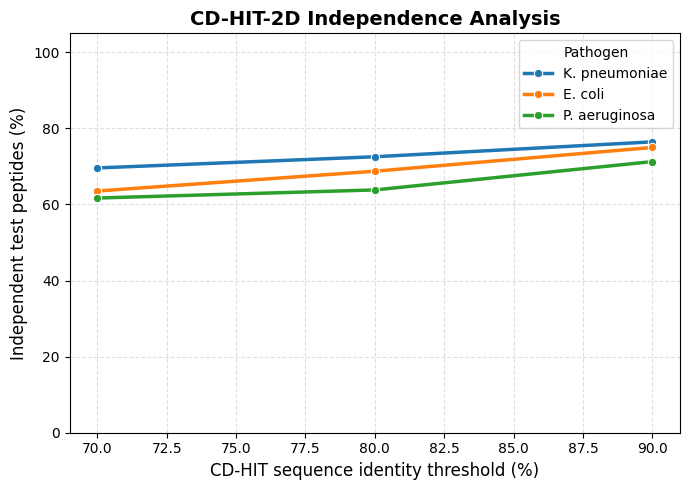

Saved: /content/CDHIT_all_results/CDHIT_independent_percentage_plot.png


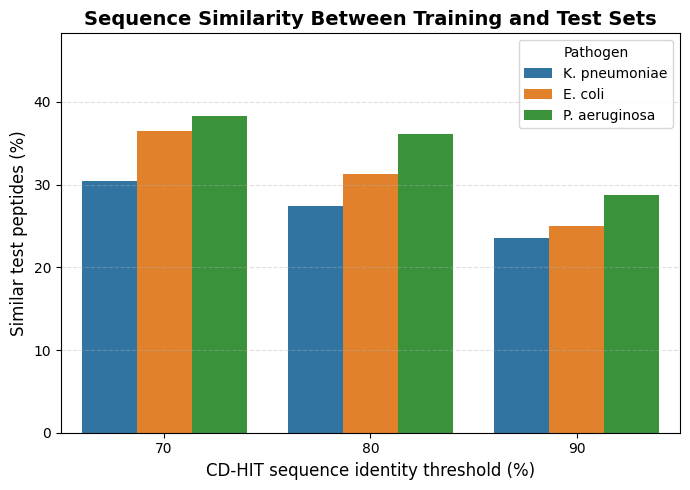

Saved: /content/CDHIT_all_results/CDHIT_similar_percentage_plot.png


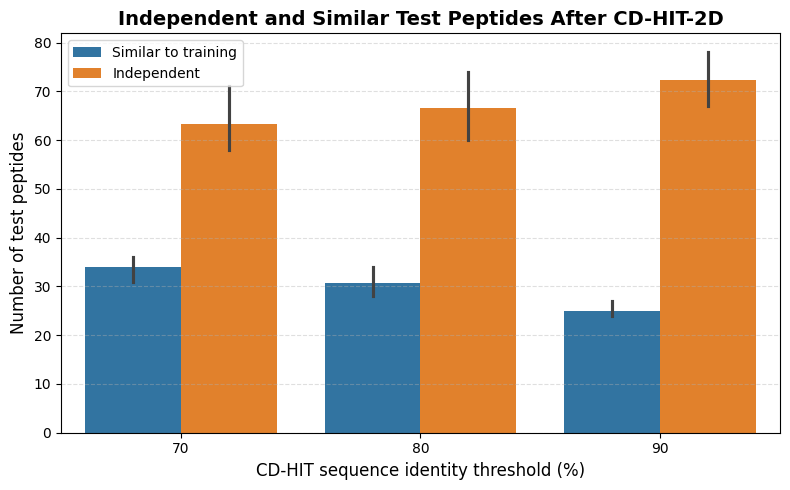

Saved: /content/CDHIT_all_results/CDHIT_similar_vs_independent_count.png


In [24]:
# ============================================================
# 6. Plot CD-HIT-2D results
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Make sure summary_df already exists
# summary_df columns:
# Dataset_code, Dataset, Threshold, Training_peptides, Test_peptides,
# Similar_test_peptides, Independent_test_peptides, Percent_similar

summary_df["Percent_independent"] = 100 - summary_df["Percent_similar"]

# ------------------------------------------------------------
# Plot 1: Independent test peptides (%)
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.lineplot(
    data=summary_df,
    x="Threshold",
    y="Percent_independent",
    hue="Dataset",
    marker="o",
    linewidth=2.5
)

plt.xlabel("CD-HIT sequence identity threshold (%)", fontsize=12)
plt.ylabel("Independent test peptides (%)", fontsize=12)
plt.title("CD-HIT-2D Independence Analysis", fontsize=14, fontweight="bold")
plt.ylim(0, 105)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(title="Pathogen")
plt.tight_layout()

plot1_path = os.path.join(output_dir, "CDHIT_independent_percentage_plot.png")
plt.savefig(plot1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", plot1_path)


# ------------------------------------------------------------
# Plot 2: Similar test peptides (%)
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.barplot(
    data=summary_df,
    x="Threshold",
    y="Percent_similar",
    hue="Dataset"
)

plt.xlabel("CD-HIT sequence identity threshold (%)", fontsize=12)
plt.ylabel("Similar test peptides (%)", fontsize=12)
plt.title("Sequence Similarity Between Training and Test Sets", fontsize=14, fontweight="bold")
plt.ylim(0, max(summary_df["Percent_similar"]) + 10)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Pathogen")
plt.tight_layout()

plot2_path = os.path.join(output_dir, "CDHIT_similar_percentage_plot.png")
plt.savefig(plot2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", plot2_path)


# ------------------------------------------------------------
# Plot 3: Similar vs Independent peptides count
# ------------------------------------------------------------

count_df = summary_df.melt(
    id_vars=["Dataset", "Threshold"],
    value_vars=["Similar_test_peptides", "Independent_test_peptides"],
    var_name="CDHIT_result",
    value_name="Number_of_peptides"
)

count_df["CDHIT_result"] = count_df["CDHIT_result"].replace({
    "Similar_test_peptides": "Similar to training",
    "Independent_test_peptides": "Independent"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=count_df,
    x="Threshold",
    y="Number_of_peptides",
    hue="CDHIT_result"
)

plt.xlabel("CD-HIT sequence identity threshold (%)", fontsize=12)
plt.ylabel("Number of test peptides", fontsize=12)
plt.title("Independent and Similar Test Peptides After CD-HIT-2D", fontsize=14, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="")
plt.tight_layout()

plot3_path = os.path.join(output_dir, "CDHIT_similar_vs_independent_count.png")
plt.savefig(plot3_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", plot3_path)